In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
data = pd.read_csv('../datasets/latinbiota_merge_metaphlan_data.csv', sep = '\t', skiprows=1, index_col = 0)
metadata = pd.read_excel('../data/metadata_LATINBIOTA_MEXICO.xlsx', sheet_name='Data')

In [3]:
data_sp = data[data.index.astype(str).str.contains("s__")]
data_sp = data_sp[~data_sp.index.astype(str).str.contains("t__")]

In [4]:
new = []

for item in data_sp.index:
    new.append(item.split('|s__')[1].replace('|t__', ' ').replace('_', ' '))

In [5]:
data_sp.index = new

In [6]:
data_sp = data_sp.T

In [7]:
data_sp.describe()

,Bacteroides stercoris,Bacteroides fragilis,Phocaeicola dorei,Fusicatenibacter saccharivorans,Bifidobacterium catenulatum,Bifidobacterium longum,Bacteroides uniformis,Hominilimicola fabiformis,Phocaeicola vulgatus,GGB4605 SGB6376,...,GGB142492 SGB209050,GGB9763 SGB15380,GGB101460 SGB144969,GGB4536 SGB6250,GGB100295 SGB144473,GGB79087 SGB105683,GGB18111 SGB26758,GGB13711 SGB21070,Fusobacterium sp oral taxon 370,Pauljensenia hongkongensis
count,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.00000,205.000000,...,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000
mean,0.302437,0.252497,0.230198,0.886656,0.464031,0.486374,0.376618,0.189591,0.74852,0.052037,...,0.000002,0.002534,0.000244,0.000206,0.000075,0.000073,0.000064,0.000021,0.000182,0.000004
std,2.110369,1.288554,0.849760,1.435396,5.278551,1.437603,0.940545,0.417210,2.11924,0.277294,...,0.000034,0.036282,0.003495,0.002947,0.001075,0.001050,0.000916,0.000307,0.002607,0.000060
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.102570,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.389630,0.000000,0.000000,0.000000,0.034690,0.00000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.000000,0.003820,0.013330,1.078580,0.000000,0.185280,0.248070,0.177580,0.49352,0.003620,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,27.443380,9.507360,7.148350,11.217700,75.321830,12.160230,6.448890,4.155660,24.01975,3.392420,...,0.000480,0.519480,0.050040,0.042200,0.015390,0.015030,0.013120,0.004390,0.037330,0.000860


In [8]:
rare = ['37082_3#16',
'37082_2#4',
'37035_2#22',
'37035_7#18',
'36703_3#20',
'36703_3#4']

In [9]:
order = list(pd.read_csv('../datasets/metadata.csv')['SampleID'])

In [10]:
data_sp2 = data_sp.loc[[x for x in order if x in data_sp.index]]

In [11]:
data_sp2 = data_sp2.drop(rare)

In [12]:
#data_sp2.to_csv('../datasets/metaphlan_species.tsv', sep = '\t')

In [13]:
data_sp2

,Bacteroides stercoris,Bacteroides fragilis,Phocaeicola dorei,Fusicatenibacter saccharivorans,Bifidobacterium catenulatum,Bifidobacterium longum,Bacteroides uniformis,Hominilimicola fabiformis,Phocaeicola vulgatus,GGB4605 SGB6376,...,GGB142492 SGB209050,GGB9763 SGB15380,GGB101460 SGB144969,GGB4536 SGB6250,GGB100295 SGB144473,GGB79087 SGB105683,GGB18111 SGB26758,GGB13711 SGB21070,Fusobacterium sp oral taxon 370,Pauljensenia hongkongensis
37082_3#9,0.00000,0.00000,0.00000,0.44033,0.00000,0.00672,0.00000,0.07789,0.00000,0.00000,...,0.0,0.00000,0.00000,0.0000,0.00000,0.00000,0.00000,0.00000,0.03733,0.00086
37082_3#8,0.00000,0.00000,0.00000,0.11622,0.00000,0.00000,0.00000,0.00000,0.00000,0.02274,...,0.0,0.00000,0.00000,0.0000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000
37082_3#7,0.00000,0.00000,0.00000,0.02854,0.00000,0.00000,0.00000,0.00838,0.00000,0.00000,...,0.0,0.51948,0.05004,0.0422,0.01539,0.01503,0.01312,0.00439,0.00000,0.00000
37082_3#6,0.00000,0.00000,0.00000,0.03441,0.03677,0.00000,0.00917,0.21087,0.00000,0.01095,...,0.0,0.00000,0.00000,0.0000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000
37082_3#5,0.00000,9.40124,0.00000,0.71803,0.00000,0.00000,0.00000,0.00000,0.60428,0.01933,...,0.0,0.00000,0.00000,0.0000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
36703_3#14,0.00000,0.00000,0.00000,0.32470,0.00000,0.70472,0.00000,0.08696,0.00430,0.00000,...,0.0,0.00000,0.00000,0.0000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000
36703_3#13,0.00000,0.00000,0.00000,0.05598,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,...,0.0,0.00000,0.00000,0.0000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000
36703_3#12,0.00000,0.00000,0.00000,1.51950,0.00000,0.00000,0.00000,0.02314,0.00000,0.00000,...,0.0,0.00000,0.00000,0.0000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000
36703_3#10,11.70371,9.50736,6.64800,6.56191,6.21521,4.98491,4.64989,4.15566,3.52507,3.39242,...,0.0,0.00000,0.00000,0.0000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000


In [14]:
labels = []
for id_ in data_sp2.index:
    labels.append(metadata[metadata['Lane'] == id_]['Lifestyle'].iloc[0])

In [15]:
pd.DataFrame(zip(data_sp2.index, labels), columns = ['SampleID', 'Lifestyle']).to_csv('../datasets/metadata_final.csv', index = False)

In [16]:
stds = data_sp.std()

In [17]:
stds.max()

np.float64(15.368340717751737)

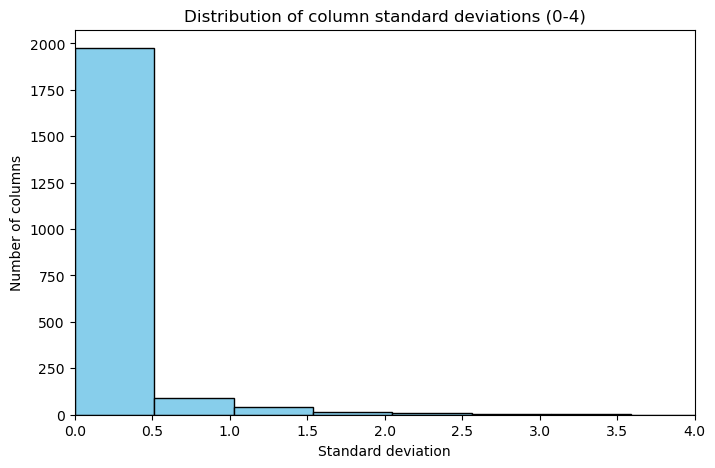

In [18]:
plt.figure(figsize=(8,5))
plt.hist(stds, bins=30, color='skyblue', edgecolor='black')
plt.xlim(0, 4)  # Focus x-axis between 0 and 4
plt.xlabel("Standard deviation")
plt.ylabel("Number of columns")
plt.title("Distribution of column standard deviations (0-4)")
plt.show()

In [19]:
metadata = pd.read_excel('../data/metadata_LATINBIOTA_MEXICO.xlsx', sheet_name='Data')

In [20]:
rare = ['37082_3#16',
'37082_2#4',
'37035_2#22',
'37035_7#18',
'36703_3#20',
'36703_3#4']

In [21]:
for id_ in rare:
    try:
        data_sp.drop(id_, axis = 0, inplace = True)
    except:
        pass

In [22]:
nonzero_counts = (data_sp > 0).sum(axis=0)

# Keep only columns present in more than 20 samples
data_sp_top = data_sp.loc[:, nonzero_counts > 10]

print(f"Original number of features: {data_sp.shape[1]}")
print(f"Filtered number of features: {data_sp_top.shape[1]}")

Original number of features: 2146
Filtered number of features: 941


In [23]:
data_sp_top

,Bacteroides stercoris,Bacteroides fragilis,Phocaeicola dorei,Fusicatenibacter saccharivorans,Bifidobacterium catenulatum,Bifidobacterium longum,Bacteroides uniformis,Hominilimicola fabiformis,Phocaeicola vulgatus,GGB4605 SGB6376,...,Christensenella minuta,Anaeromassilibacillus senegalensis,Hydrogenoanaerobacterium saccharovorans,GGB1497 SGB2076,Bacteroides clarus,Eisenbergiella massiliensis,Clostridium sp AT4,Enterocloster citroniae,GGB1669 SGB2285,GGB13787 SGB146465
36703_3#10,11.70371,9.50736,6.648,6.56191,6.21521,4.98491,4.64989,4.15566,3.52507,3.39242,...,0.0,0.0,0.0,0.00000,0.0,0.0,0.0,0.0,0.0,0.00000
36703_3#12,0.00000,0.00000,0.000,1.51950,0.00000,0.00000,0.00000,0.02314,0.00000,0.00000,...,0.0,0.0,0.0,0.00000,0.0,0.0,0.0,0.0,0.0,0.00000
36703_3#13,0.00000,0.00000,0.000,0.05598,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,...,0.0,0.0,0.0,0.00000,0.0,0.0,0.0,0.0,0.0,0.00000
36703_3#14,0.00000,0.00000,0.000,0.32470,0.00000,0.70472,0.00000,0.08696,0.00430,0.00000,...,0.0,0.0,0.0,0.00000,0.0,0.0,0.0,0.0,0.0,0.00000
36703_3#15,0.00000,0.00000,0.000,0.59237,0.00000,2.01763,0.00000,1.44976,0.00000,0.00000,...,0.0,0.0,0.0,0.00000,0.0,0.0,0.0,0.0,0.0,0.00000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
37082_3#5,0.00000,9.40124,0.000,0.71803,0.00000,0.00000,0.00000,0.00000,0.60428,0.01933,...,0.0,0.0,0.0,0.00000,0.0,0.0,0.0,0.0,0.0,0.00000
37082_3#6,0.00000,0.00000,0.000,0.03441,0.03677,0.00000,0.00917,0.21087,0.00000,0.01095,...,0.0,0.0,0.0,0.00000,0.0,0.0,0.0,0.0,0.0,0.00000
37082_3#7,0.00000,0.00000,0.000,0.02854,0.00000,0.00000,0.00000,0.00838,0.00000,0.00000,...,0.0,0.0,0.0,1.02521,0.0,0.0,0.0,0.0,0.0,0.00606
37082_3#8,0.00000,0.00000,0.000,0.11622,0.00000,0.00000,0.00000,0.00000,0.00000,0.02274,...,0.0,0.0,0.0,0.05814,0.0,0.0,0.0,0.0,0.0,0.00000


In [24]:
rural = list(metadata[metadata['Lifestyle'] == 'Rural']['Lane'])
urban = list(metadata[metadata['Lifestyle'] == 'Urban']['Lane'])

In [25]:
label = []
for x in data_sp_top.index:
    if x in rural:
        label.append('Rural')
    elif x in urban:
        label.append('Urban')
    else:
        label.append('None')
        

In [26]:
data_sp_top['label'] = label

C:\Users\rafap\AppData\Local\Temp\ipykernel_7980\1295263056.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_sp_top['label'] = label


In [27]:
import math
age_group_list = []
for id_ in data_sp_top.index:
    try:
        if math.isnan(metadata[metadata['Lane'] == id_]['Age group'].iloc[0]):
            age_group_list.append('Adult')
    except:
        if metadata[metadata['Lane'] == id_]['Age group'].iloc[0] == 'Infant':
            age_group_list.append('Child')
        elif metadata[metadata['Lane'] == id_]['Age group'].iloc[0] == 'Teenager':
            age_group_list.append('Adult')
        else:
            age_group_list.append(metadata[metadata['Lane'] == id_]['Age group'].iloc[0])
        
    # age_group_list.append(metadata[metadata['Lane'] == id_]['Age group'].iloc[0])

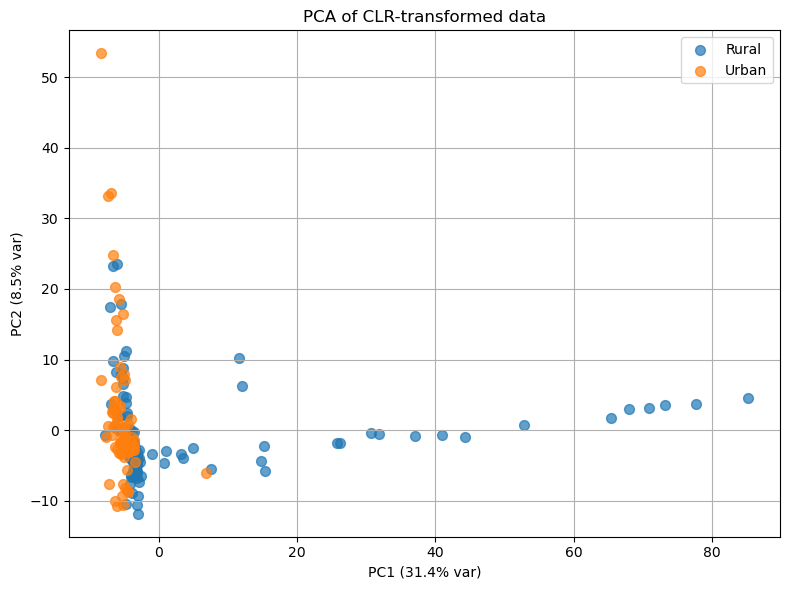

In [28]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np

# CLR transformation function
def clr_transform(X):
    """
    Apply Centered Log-Ratio (CLR) transformation to compositional data.
    
    Parameters:
    X : array-like, shape (n_samples, n_features)
        Compositional data (must be positive)
    
    Returns:
    X_clr : array, CLR-transformed data
    """
    # Add small constant to avoid log(0) if there are zeros
    X_safe = X + 1e-6
    
    # Compute geometric mean for each sample (row)
    geom_mean = np.exp(np.mean(np.log(X_safe), axis=1, keepdims=True))
    
    # CLR: log(x_i / geometric_mean)
    X_clr = np.log(X_safe / geom_mean)
    
    return X_clr

# Separate features and labels
X = data_sp_top.drop(columns=['label']).values
y = data_sp_top['label'].values

# 1. Apply CLR transformation
X_clr = X
# X_clr = clr_transform(X)

# 2. Optional: Standardization (uncomment if needed)
# scaler = StandardScaler()
# X_clr = scaler.fit_transform(X_clr)

# 3. Perform PCA (2 components)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_clr)

# Make a scatter plot
plt.figure(figsize=(8,6))

# Map unique labels to colors
labels_unique = sorted(set(y))
colors = plt.cm.tab10.colors  # up to 10 colors

for i, lbl in enumerate(labels_unique):
    idx = y == lbl
    plt.scatter(X_pca[idx,0], X_pca[idx,1], 
                label=lbl, 
                color=colors[i % len(colors)], 
                alpha=0.7, s=50)

plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)')
plt.title('PCA of CLR-transformed data')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

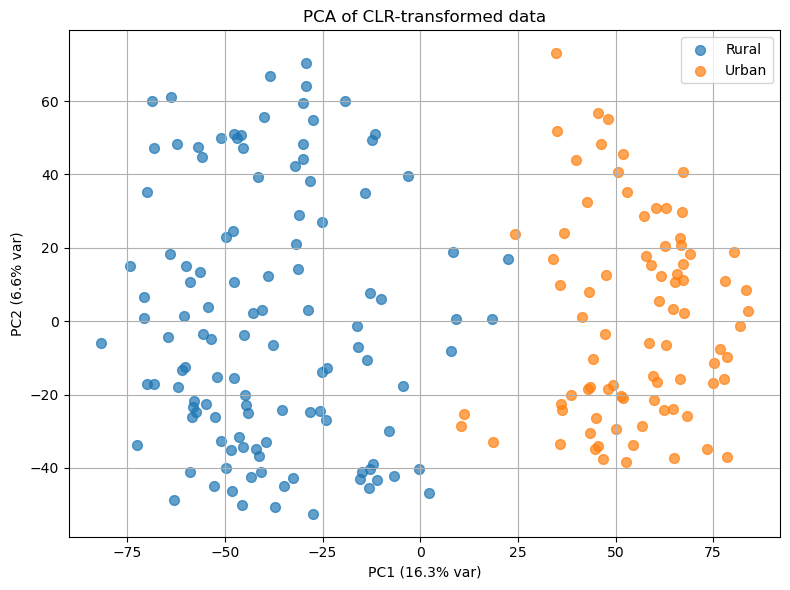

In [29]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np

# CLR transformation function
def clr_transform(X):
    """
    Apply Centered Log-Ratio (CLR) transformation to compositional data.
    
    Parameters:
    X : array-like, shape (n_samples, n_features)
        Compositional data (must be positive)
    
    Returns:
    X_clr : array, CLR-transformed data
    """
    # Add small constant to avoid log(0) if there are zeros
    X_safe = X + 1e-6
    
    # Compute geometric mean for each sample (row)
    geom_mean = np.exp(np.mean(np.log(X_safe), axis=1, keepdims=True))
    
    # CLR: log(x_i / geometric_mean)
    X_clr = np.log(X_safe / geom_mean)
    
    return X_clr

# Separate features and labels
X = data_sp_top.drop(columns=['label']).values
y = data_sp_top['label'].values

# 1. Apply CLR transformation
# X_clr = X
X_clr = clr_transform(X)

# 2. Optional: Standardization (uncomment if needed)
# scaler = StandardScaler()
# X_clr = scaler.fit_transform(X_clr)

# 3. Perform PCA (2 components)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_clr)

# Make a scatter plot
plt.figure(figsize=(8,6))

# Map unique labels to colors
labels_unique = sorted(set(y))
colors = plt.cm.tab10.colors  # up to 10 colors

for i, lbl in enumerate(labels_unique):
    idx = y == lbl
    plt.scatter(X_pca[idx,0], X_pca[idx,1], 
                label=lbl, 
                color=colors[i % len(colors)], 
                alpha=0.7, s=50)

plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)')
plt.title('PCA of CLR-transformed data')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [30]:
data_sp_top['age_group'] = age_group_list

C:\Users\rafap\AppData\Local\Temp\ipykernel_7980\2344775883.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_sp_top['age_group'] = age_group_list


In [31]:
data_sp_top.drop('Age group', axis = 1, inplace = True)

KeyError: "['Age group'] not found in axis"

In [ ]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np
from matplotlib.lines import Line2D

# CLR transformation function
def clr_transform(X):
    """
    Apply Centered Log-Ratio (CLR) transformation to compositional data.
    
    Parameters:
    X : array-like, shape (n_samples, n_features)
        Compositional data (must be positive)
    
    Returns:
    X_clr : array, CLR-transformed data
    """
    # Add small constant to avoid log(0) if there are zeros
    X_safe = X + 1e-6
    
    # Compute geometric mean for each sample (row)
    geom_mean = np.exp(np.mean(np.log(X_safe), axis=1, keepdims=True))
    
    # CLR: log(x_i / geometric_mean)
    X_clr = np.log(X_safe / geom_mean)
    
    return X_clr

# Separate features and labels
X = data_sp_top.drop(columns=['label', 'age_group']).values
y = data_sp_top['label'].values
age_group = data_sp_top['age_group'].values  # Make sure this column exists

# 1. Apply CLR transformation
X_clr = clr_transform(X)

# 2. Optional: Standardization (uncomment if needed)
# scaler = StandardScaler()
# X_clr = scaler.fit_transform(X_clr)

# 3. Perform PCA (2 components)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_clr)

# Set journal-style parameters
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans']
plt.rcParams['font.size'] = 10
plt.rcParams['axes.linewidth'] = 1.0
plt.rcParams['xtick.major.width'] = 1.0
plt.rcParams['ytick.major.width'] = 1.0
plt.rcParams['xtick.major.size'] = 4
plt.rcParams['ytick.major.size'] = 4

# Create figure with specific size (suitable for journal column width)
fig, ax = plt.subplots(figsize=(5, 3.5), dpi=300)

# Map unique labels to colors
labels_unique = sorted(set(y))
colors = plt.cm.Set2.colors if len(labels_unique) <= 8 else plt.cm.tab10.colors

# Map unique age groups to markers
age_groups_unique = sorted(set(age_group))
markers = ['o', 's', '^', 'D', 'v', '<', '>', 'p', '*', 'h']

# Plot each combination of label and age group
for i, lbl in enumerate(labels_unique):
    for j, age in enumerate(age_groups_unique):
        idx = (y == lbl) & (age_group == age)
        
        if np.any(idx):
            marker_style = markers[j % len(markers)]
            color = colors[i % len(colors)]
            
            ax.scatter(X_pca[idx, 0], X_pca[idx, 1],
                      color=color,
                      marker=marker_style,
                      alpha=0.7,
                      s=25,
                      edgecolors='white',
                      linewidths=0.5)

# Create custom legend elements AFTER plotting
# Legend for labels (colors)
label_legend_elements = [Line2D([0], [0], marker='o', color='w', 
                                markerfacecolor=colors[i % len(colors)], 
                                markersize=8, label=lbl,
                                markeredgecolor='white', markeredgewidth=0.5)
                        for i, lbl in enumerate(labels_unique)]

# Legend for age groups (markers)
age_legend_elements = [Line2D([0], [0], marker=markers[j % len(markers)], 
                              color='w', markerfacecolor='gray', 
                              markersize=8, label=age,
                              markeredgecolor='white', markeredgewidth=0.5)
                      for j, age in enumerate(age_groups_unique)]

# Add first legend (labels)
first_legend = ax.legend(handles=label_legend_elements, 
                        title='Label',
                        loc='upper left',
                        bbox_to_anchor=(1.02, 1),
                        fontsize=8,
                        title_fontsize=9,
                        frameon=True,
                        edgecolor='black',
                        fancybox=False,
                        framealpha=0.9)

# Add second legend (age groups)
ax.add_artist(first_legend)  # Keep first legend
ax.legend(handles=age_legend_elements,
         title='Age Group',
         loc='upper left',
         bbox_to_anchor=(1.02, 0.55),
         fontsize=8,
         title_fontsize=9,
         frameon=True,
         edgecolor='black',
         fancybox=False,
         framealpha=0.9)

# Format axes
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)', 
              fontsize=11, fontweight='bold')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)', 
              fontsize=11, fontweight='bold')

# Remove top and right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Add subtle grid
ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

# Optional: Save as high-resolution files for publication
# fig.savefig('pca_clr_analysis.pdf', dpi=300, bbox_inches='tight')
fig.savefig('pca_clr_analysis.png', dpi=400, bbox_inches='tight')
# fig.savefig('pca_clr_analysis.svg', bbox_inches='tight')

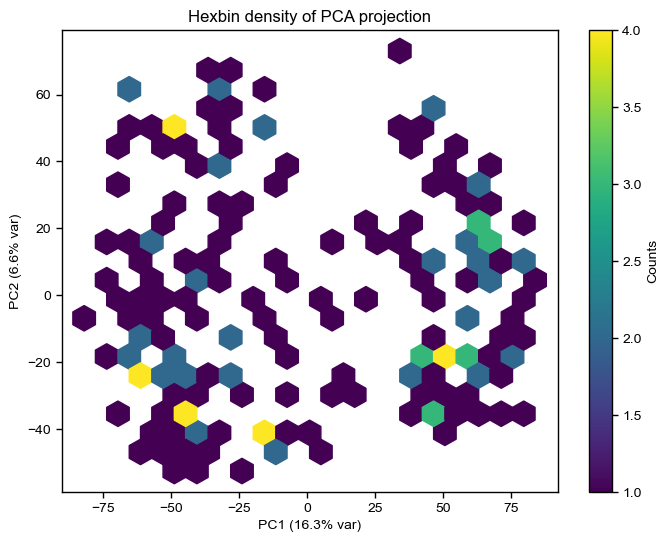

In [76]:
import matplotlib.pyplot as plt

# X_pca from previous PCA
x = X_pca[:,0]
y = X_pca[:,1]

plt.figure(figsize=(8,6))
hb = plt.hexbin(x, y, gridsize=20, cmap='viridis', mincnt=1)
plt.colorbar(hb, label='Counts')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)')
plt.title('Hexbin density of PCA projection')
plt.show()


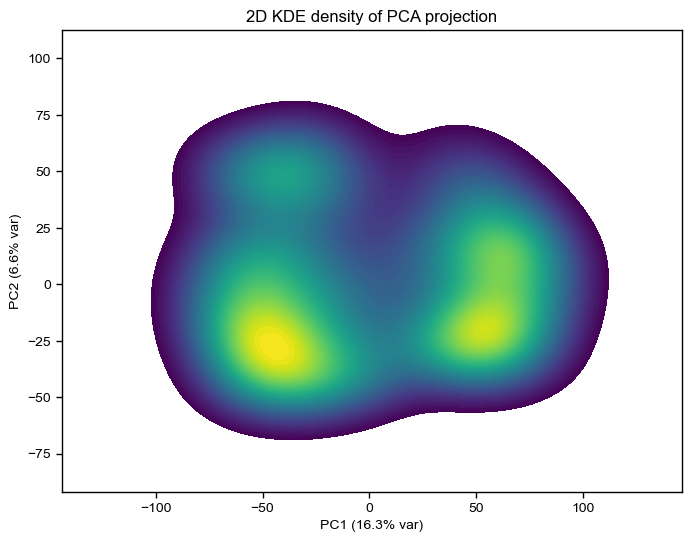

In [77]:
import seaborn as sns

plt.figure(figsize=(8,6))
sns.kdeplot(x=x, y=y, fill=True, cmap='viridis', thresh=0.05, levels=100)
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)')
plt.title('2D KDE density of PCA projection')
plt.show()

In [78]:
df_plot = pd.DataFrame({
    'PC1': X_pca[:,0],
    'PC2': X_pca[:,1],
    'label': label
})
df_plot

,PC1,PC2,label
0,50.034001,-29.360659,1
1,-28.777015,2.955334,1
2,-13.719646,-10.667365,1
3,-12.801395,-40.270722,1
4,-0.415144,-40.390302,1
...,...,...,...
194,-29.972763,48.411197,1
195,-28.295625,-24.745031,1
196,-68.231609,47.186140,1
197,-68.577924,59.910302,1


C:\Users\rafap\anaconda3\envs\clustering-env\Lib\site-packages\seaborn\distributions.py:1128: UserWarning: cmap parameter ignored when using hue mapping.
  warnings.warn(msg, UserWarning)


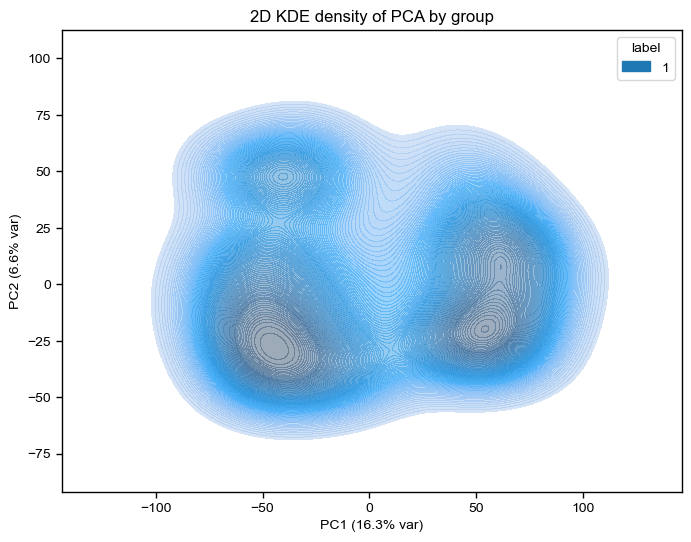

In [79]:
import seaborn as sns
import pandas as pd

df_plot = pd.DataFrame({
    'PC1': X_pca[:,0],
    'PC2': X_pca[:,1],
    'label': label
})

plt.figure(figsize=(8,6))
sns.kdeplot(data=df_plot, x='PC1', y='PC2', hue='label', fill=True, alpha=0.5, cmap='coolwarm', levels=100)
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)')
plt.title('2D KDE density of PCA by group')
plt.show()


C:\Users\rafap\anaconda3\envs\clustering-env\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


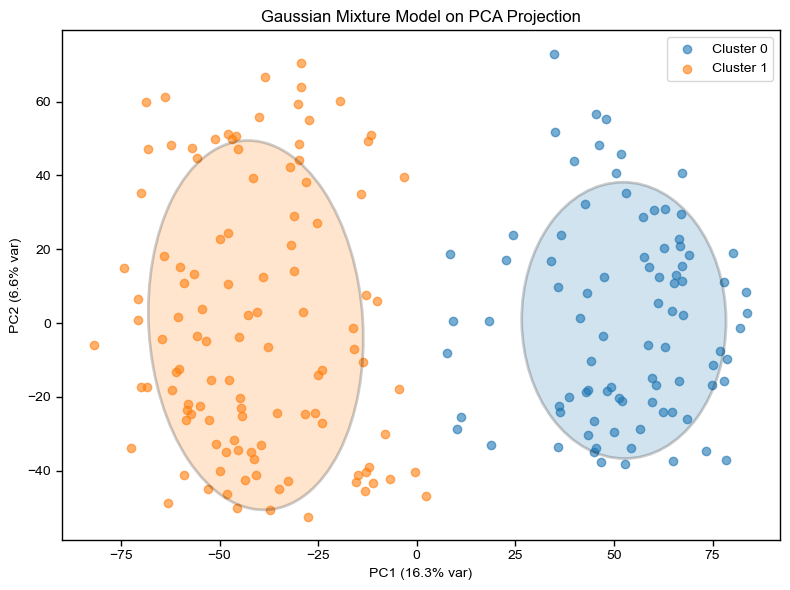

In [80]:
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
from sklearn.decomposition import PCA
from sklearn.mixture import GaussianMixture
import numpy as np

# Ajustar el modelo GMM
gmm = GaussianMixture(n_components=2, random_state=42)
gmm.fit(X_clr)

# Proyección PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_clr)

# Predicciones del GMM
labels_pred = gmm.predict(X_clr)

# Transformar medias y covarianzas del GMM al espacio PCA
means_pca = pca.transform(gmm.means_)
covariances_pca = []
for cov in gmm.covariances_:
    # Transformar covarianza: C' = P * C * P^T (donde P son los componentes PCA)
    cov_pca = pca.components_ @ cov @ pca.components_.T
    covariances_pca.append(cov_pca)

# Gráfico
plt.figure(figsize=(8, 6))
colors = plt.cm.tab10.colors

for i, label in enumerate(np.unique(labels_pred)):
    idx = labels_pred == label
    plt.scatter(X_pca[idx, 0], X_pca[idx, 1],
                color=colors[i % len(colors)], label=f'Cluster {label}', alpha=0.6)
    
    # Dibujar elipsoides de covarianza en el espacio PCA
    cov_2d = covariances_pca[label]
    mean_2d = means_pca[label]
    
    # Calcular autovalores y autovectores
    v, w = np.linalg.eigh(cov_2d)
    v = 2.0 * np.sqrt(2.0) * np.sqrt(v)  # Escalar para ~95% de confianza
    angle = np.degrees(np.arctan2(w[1, 0], w[0, 0]))
    
    ellipse = Ellipse(mean_2d, v[0], v[1], angle=angle,
                      alpha=0.2, facecolor=colors[i % len(colors)], 
                      edgecolor='black', linewidth=2)
    plt.gca().add_artist(ellipse)

plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)')
plt.title('Gaussian Mixture Model on PCA Projection')
plt.legend()
plt.tight_layout()
plt.show()

C:\Users\rafap\anaconda3\envs\clustering-env\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\rafap\anaconda3\envs\clustering-env\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\rafap\anaconda3\envs\clustering-env\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\rafap\anaconda3\envs\clustering-env\Lib\site-packages\sklearn\clust

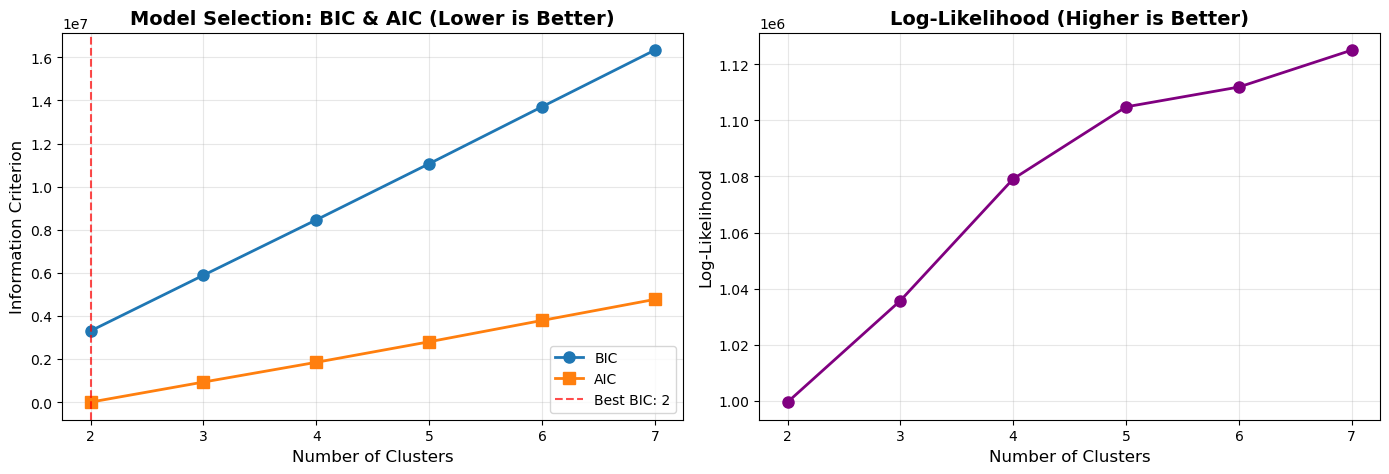

GMM EVALUATION RESULTS
Clusters   BIC             AIC             Log-Likelihood 
------------------------------------------------------------
2          3310097.62      6909.59         999546.21      
3          5892325.38      937541.68       1035731.16     
4          8460122.88      1853743.52      1079131.24     
5          11063383.02     2805408.00      1104800.00     
6          13703848.56     3794277.87      1111866.06     
7          16332126.62     4770960.27      1125025.86     

RECOMMENDATIONS:
Best by BIC (recommended): 2 clusters
Best by AIC:               2 clusters
Best by Log-Likelihood:    7 clusters

Note: BIC is typically preferred as it penalizes model complexity
more heavily, helping avoid overfitting.


In [129]:
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture
import numpy as np

# Rango de clusters a evaluar
n_clusters_range = range(2, 8)  # 2, 3, 4

# Listas para almacenar métricas
bic_scores = []
aic_scores = []
log_likelihood_scores = []

# Evaluar cada número de clusters
for n in n_clusters_range:
    # Ajustar GMM
    gmm = GaussianMixture(n_components=n, random_state=42)
    gmm.fit(X_clr)
    
    # Calcular métricas apropiadas para GMM
    bic_scores.append(gmm.bic(X_clr))
    aic_scores.append(gmm.aic(X_clr))
    log_likelihood_scores.append(gmm.score(X_clr) * len(X_clr))  # Total log-likelihood

# Crear figura con 2 subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: BIC y AIC (lower is better)
axes[0].plot(list(n_clusters_range), bic_scores, 'o-', label='BIC', linewidth=2, markersize=8)
axes[0].plot(list(n_clusters_range), aic_scores, 's-', label='AIC', linewidth=2, markersize=8)
axes[0].set_xlabel('Number of Clusters', fontsize=12)
axes[0].set_ylabel('Information Criterion', fontsize=12)
axes[0].set_title('Model Selection: BIC & AIC (Lower is Better)', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].set_xticks(list(n_clusters_range))

# Marcar el mínimo BIC
best_bic_idx = np.argmin(bic_scores)
best_bic_n = list(n_clusters_range)[best_bic_idx]
axes[0].axvline(best_bic_n, color='red', linestyle='--', alpha=0.7, 
                label=f'Best BIC: {best_bic_n}')
axes[0].legend()

# Plot 2: Log-Likelihood (higher is better)
axes[1].plot(list(n_clusters_range), log_likelihood_scores, 'o-', 
             color='purple', linewidth=2, markersize=8)
axes[1].set_xlabel('Number of Clusters', fontsize=12)
axes[1].set_ylabel('Log-Likelihood', fontsize=12)
axes[1].set_title('Log-Likelihood (Higher is Better)', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)
axes[1].set_xticks(list(n_clusters_range))

plt.tight_layout()
plt.show()

# Imprimir resultados
print("=" * 60)
print("GMM EVALUATION RESULTS")
print("=" * 60)
print(f"{'Clusters':<10} {'BIC':<15} {'AIC':<15} {'Log-Likelihood':<15}")
print("-" * 60)
for i, n in enumerate(n_clusters_range):
    print(f"{n:<10} {bic_scores[i]:<15.2f} {aic_scores[i]:<15.2f} {log_likelihood_scores[i]:<15.2f}")

print("\n" + "=" * 60)
print("RECOMMENDATIONS:")
print("=" * 60)
print(f"Best by BIC (recommended): {best_bic_n} clusters")
print(f"Best by AIC:               {list(n_clusters_range)[np.argmin(aic_scores)]} clusters")
print(f"Best by Log-Likelihood:    {list(n_clusters_range)[np.argmax(log_likelihood_scores)]} clusters")
print("\nNote: BIC is typically preferred as it penalizes model complexity")
print("more heavily, helping avoid overfitting.")
print("=" * 60)

In [115]:
data_sp_top['predict'] = labels_pred

C:\Users\rafap\AppData\Local\Temp\ipykernel_9768\2718241519.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_sp_top['predict'] = labels_pred


In [139]:
data_sp_top[(data_sp_top['label']=='Rural')&(data_sp_top['predict'] == 0)]

,GGB4916 SGB6868,Segatella copri,Agathobacter rectalis,Streptococcus gallolyticus,Ruminococcus bromii,Streptococcus salivarius,Faecalibacterium prausnitzii,Streptococcus lutetiensis,GGB4567 SGB6308,Escherichia coli,...,Haemophilus sputorum,GGB9122 SGB14055,GGB100899 SGB146315,GGB6006 SGB8630,GGB6014 SGB8646,Alistipes dispar,GGB36267 SGB14177,Mediterraneibacter glycyrrhizinilyticus,label,predict
37035_1#3,0.0,1.07283,7.10588,0.00000,3.40894,0.02793,1.04094,0.00000,0.0,0.80829,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Rural,0
37035_7#3,0.0,2.14995,3.61369,0.39306,0.00000,0.53036,11.25456,0.01384,0.0,0.00949,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Rural,0
37035_7#5,0.0,26.02791,6.18289,0.00000,1.55581,0.10575,6.44424,0.00000,0.0,0.00000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Rural,0
37035_7#6,0.0,0.00000,10.05428,0.00000,1.13023,0.00000,27.49145,0.00000,0.0,0.00945,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Rural,0
37082_3#14,0.0,0.12272,0.00000,0.00000,11.15556,0.00113,0.03763,0.15212,0.0,0.03410,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Rural,0


In [116]:
group1 = list(data_sp_top[data_sp_top['predict'] == 0].index)
group2 = list(data_sp_top[data_sp_top['predict'] == 1].index)
# group3 = list(data_sp_top[data_sp_top['predict'] == 2].index)
# group4 = list(data_sp_top[data_sp_top['predict'] == 3].index)

In [117]:
meta1 = metadata[metadata['Lane'].isin(group1)]
meta2 = metadata[metadata['Lane'].isin(group2)]
# meta3 = metadata[metadata['Lane'].isin(group3)]
# meta4 = metadata[metadata['Lane'].isin(group4)]


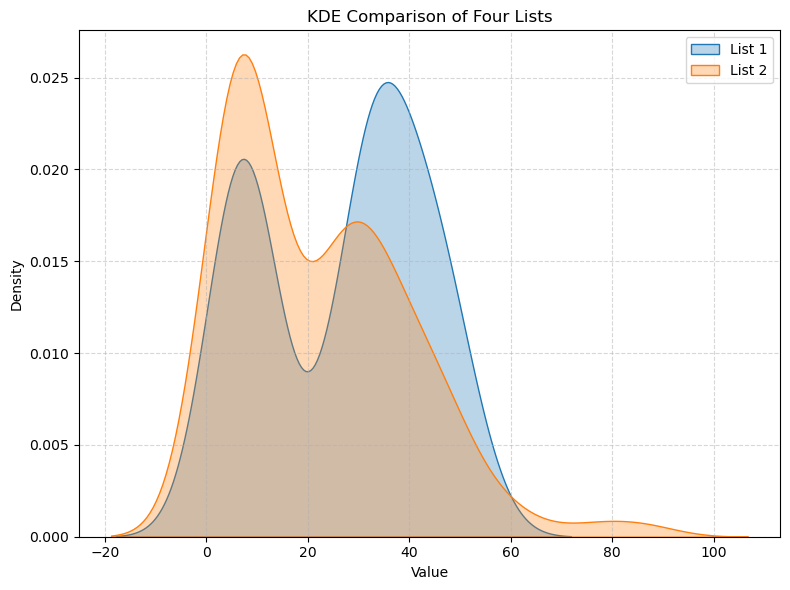

In [118]:
import seaborn as sns
import matplotlib.pyplot as plt

# Example lists
list1 = list(meta1['Age'])
list2 = list(meta2['Age'])
# list3 = list(meta3['Age'])
# list4 = list(meta4['Age'])

# Plot
plt.figure(figsize=(8,6))
sns.kdeplot(list1, label="List 1", fill=True, alpha=0.3)
sns.kdeplot(list2, label="List 2", fill=True, alpha=0.3)
# sns.kdeplot(list3, label="List 3", fill=True, alpha=0.3)
# sns.kdeplot(list4, label="List 4", fill=True, alpha=0.3)

plt.title("KDE Comparison of Four Lists")
plt.xlabel("Value")
plt.ylabel("Density")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

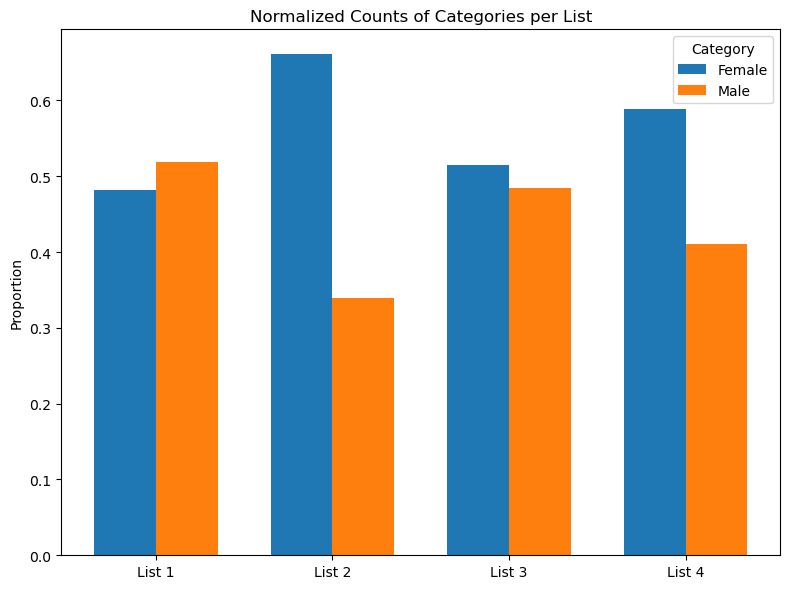

In [111]:
import matplotlib.pyplot as plt
import pandas as pd
from collections import Counter
import numpy as np

# Example categorical lists (2 categories: 'A' and 'B')
list1 = list(meta1['Gender'])
list2 = list(meta2['Gender'])
list3 = list(meta3['Gender'])
list4 = list(meta4['Gender'])

lists = [list1, list2, list3, list4]
list_names = ['List 1','List 2','List 3','List 4']

# Count occurrences ignoring NaNs
counts = pd.DataFrame([
    Counter([x for x in lst if pd.notna(x)]) for lst in lists
], index=list_names).fillna(0)

# Normalize so that each row sums to 1
counts_normalized = counts.div(counts.sum(axis=1), axis=0)

# --- Plot grouped bar chart ---
categories = counts_normalized.columns
x = np.arange(len(list_names))
width = 0.35

fig, ax = plt.subplots(figsize=(8,6))
for i, cat in enumerate(categories):
    ax.bar(x + i*width, counts_normalized[cat], width, label=cat)

ax.set_xticks(x + width/2)
ax.set_xticklabels(list_names)
ax.set_ylabel('Proportion')
ax.set_title('Normalized Counts of Categories per List')
ax.legend(title='Category')
plt.tight_layout()
plt.show()


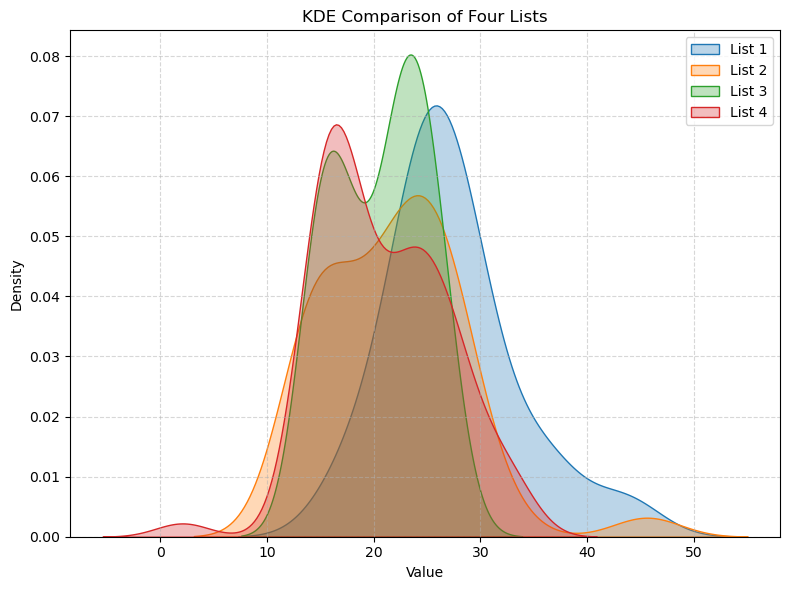

In [113]:
import seaborn as sns
import matplotlib.pyplot as plt

# Example lists
list1 = list(meta1['BMI'])
list2 = list(meta2['BMI'])
list3 = list(meta3['BMI'])
list4 = list(meta4['BMI'])

# Plot
plt.figure(figsize=(8,6))
sns.kdeplot(list1, label="List 1", fill=True, alpha=0.3)
sns.kdeplot(list2, label="List 2", fill=True, alpha=0.3)
sns.kdeplot(list3, label="List 3", fill=True, alpha=0.3)
sns.kdeplot(list4, label="List 4", fill=True, alpha=0.3)

plt.title("KDE Comparison of Four Lists")
plt.xlabel("Value")
plt.ylabel("Density")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

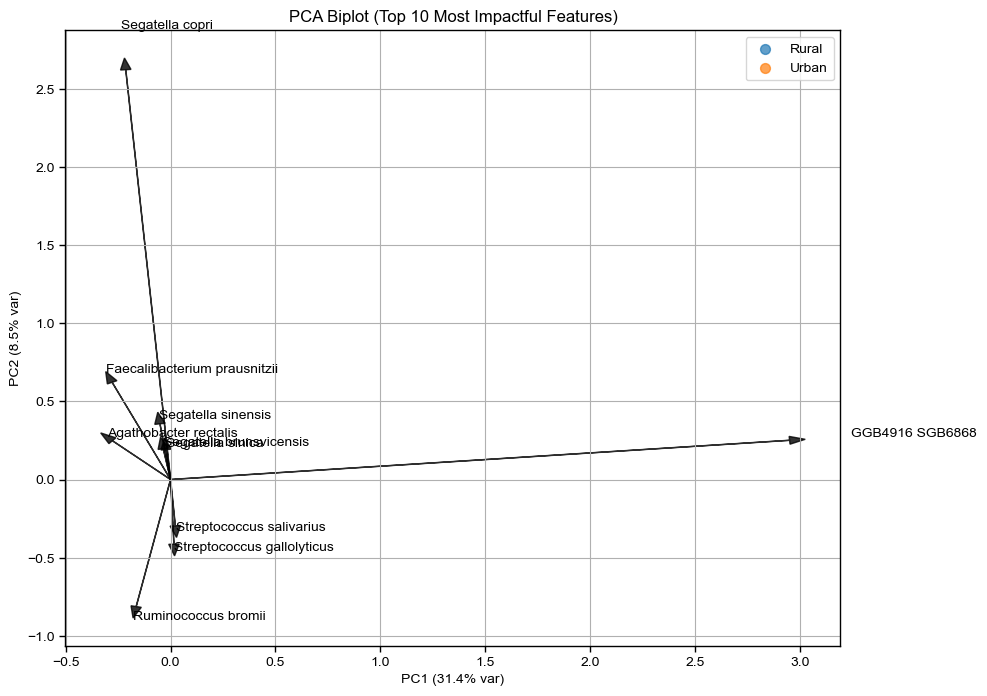

In [81]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.decomposition import PCA

# X = features only, shape (n_samples, n_features)
# labels = sample labels (e.g., Rural/Urban)

X = data_sp_top.drop(columns=['label', 'age_group']).values
y = data_sp_top['label'].values


pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)  # samples in PC1/PC2

# Loadings (contributions of original variables)
loadings = pca.components_.T  # shape: n_features x 2

# 2️⃣ Compute contribution of each feature to PC1+PC2
contrib = np.linalg.norm(loadings, axis=1)  # Euclidean norm across PCs

# 3️⃣ Select top 10 features by contribution
top_idx = np.argsort(contrib)[-10:][::-1]  # indices of top 10
top_features = data_sp_top.drop(columns='label').columns[top_idx]

# 4️⃣ Scatter plot of samples
plt.figure(figsize=(10,8))
for group in np.unique(labels):
    idx = labels == group
    plt.scatter(X_pca[idx,0], X_pca[idx,1], alpha=0.7, s=50, label=group)

# 5️⃣ Draw arrows for top 10 features
scaling = 3
for i in top_idx:
    plt.arrow(0, 0, loadings[i,0]*scaling, loadings[i,1]*scaling, color='black', alpha=0.8, head_width=0.05)
    plt.text(loadings[i,0]*scaling*1.1, loadings[i,1]*scaling*1.1, data_sp_top.drop(columns='label').columns[i],
             fontsize=10, color='black')

# 6️⃣ Labels and legend
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)')
plt.title('PCA Biplot (Top 10 Most Impactful Features)')
plt.grid(True)
plt.legend()
plt.show()


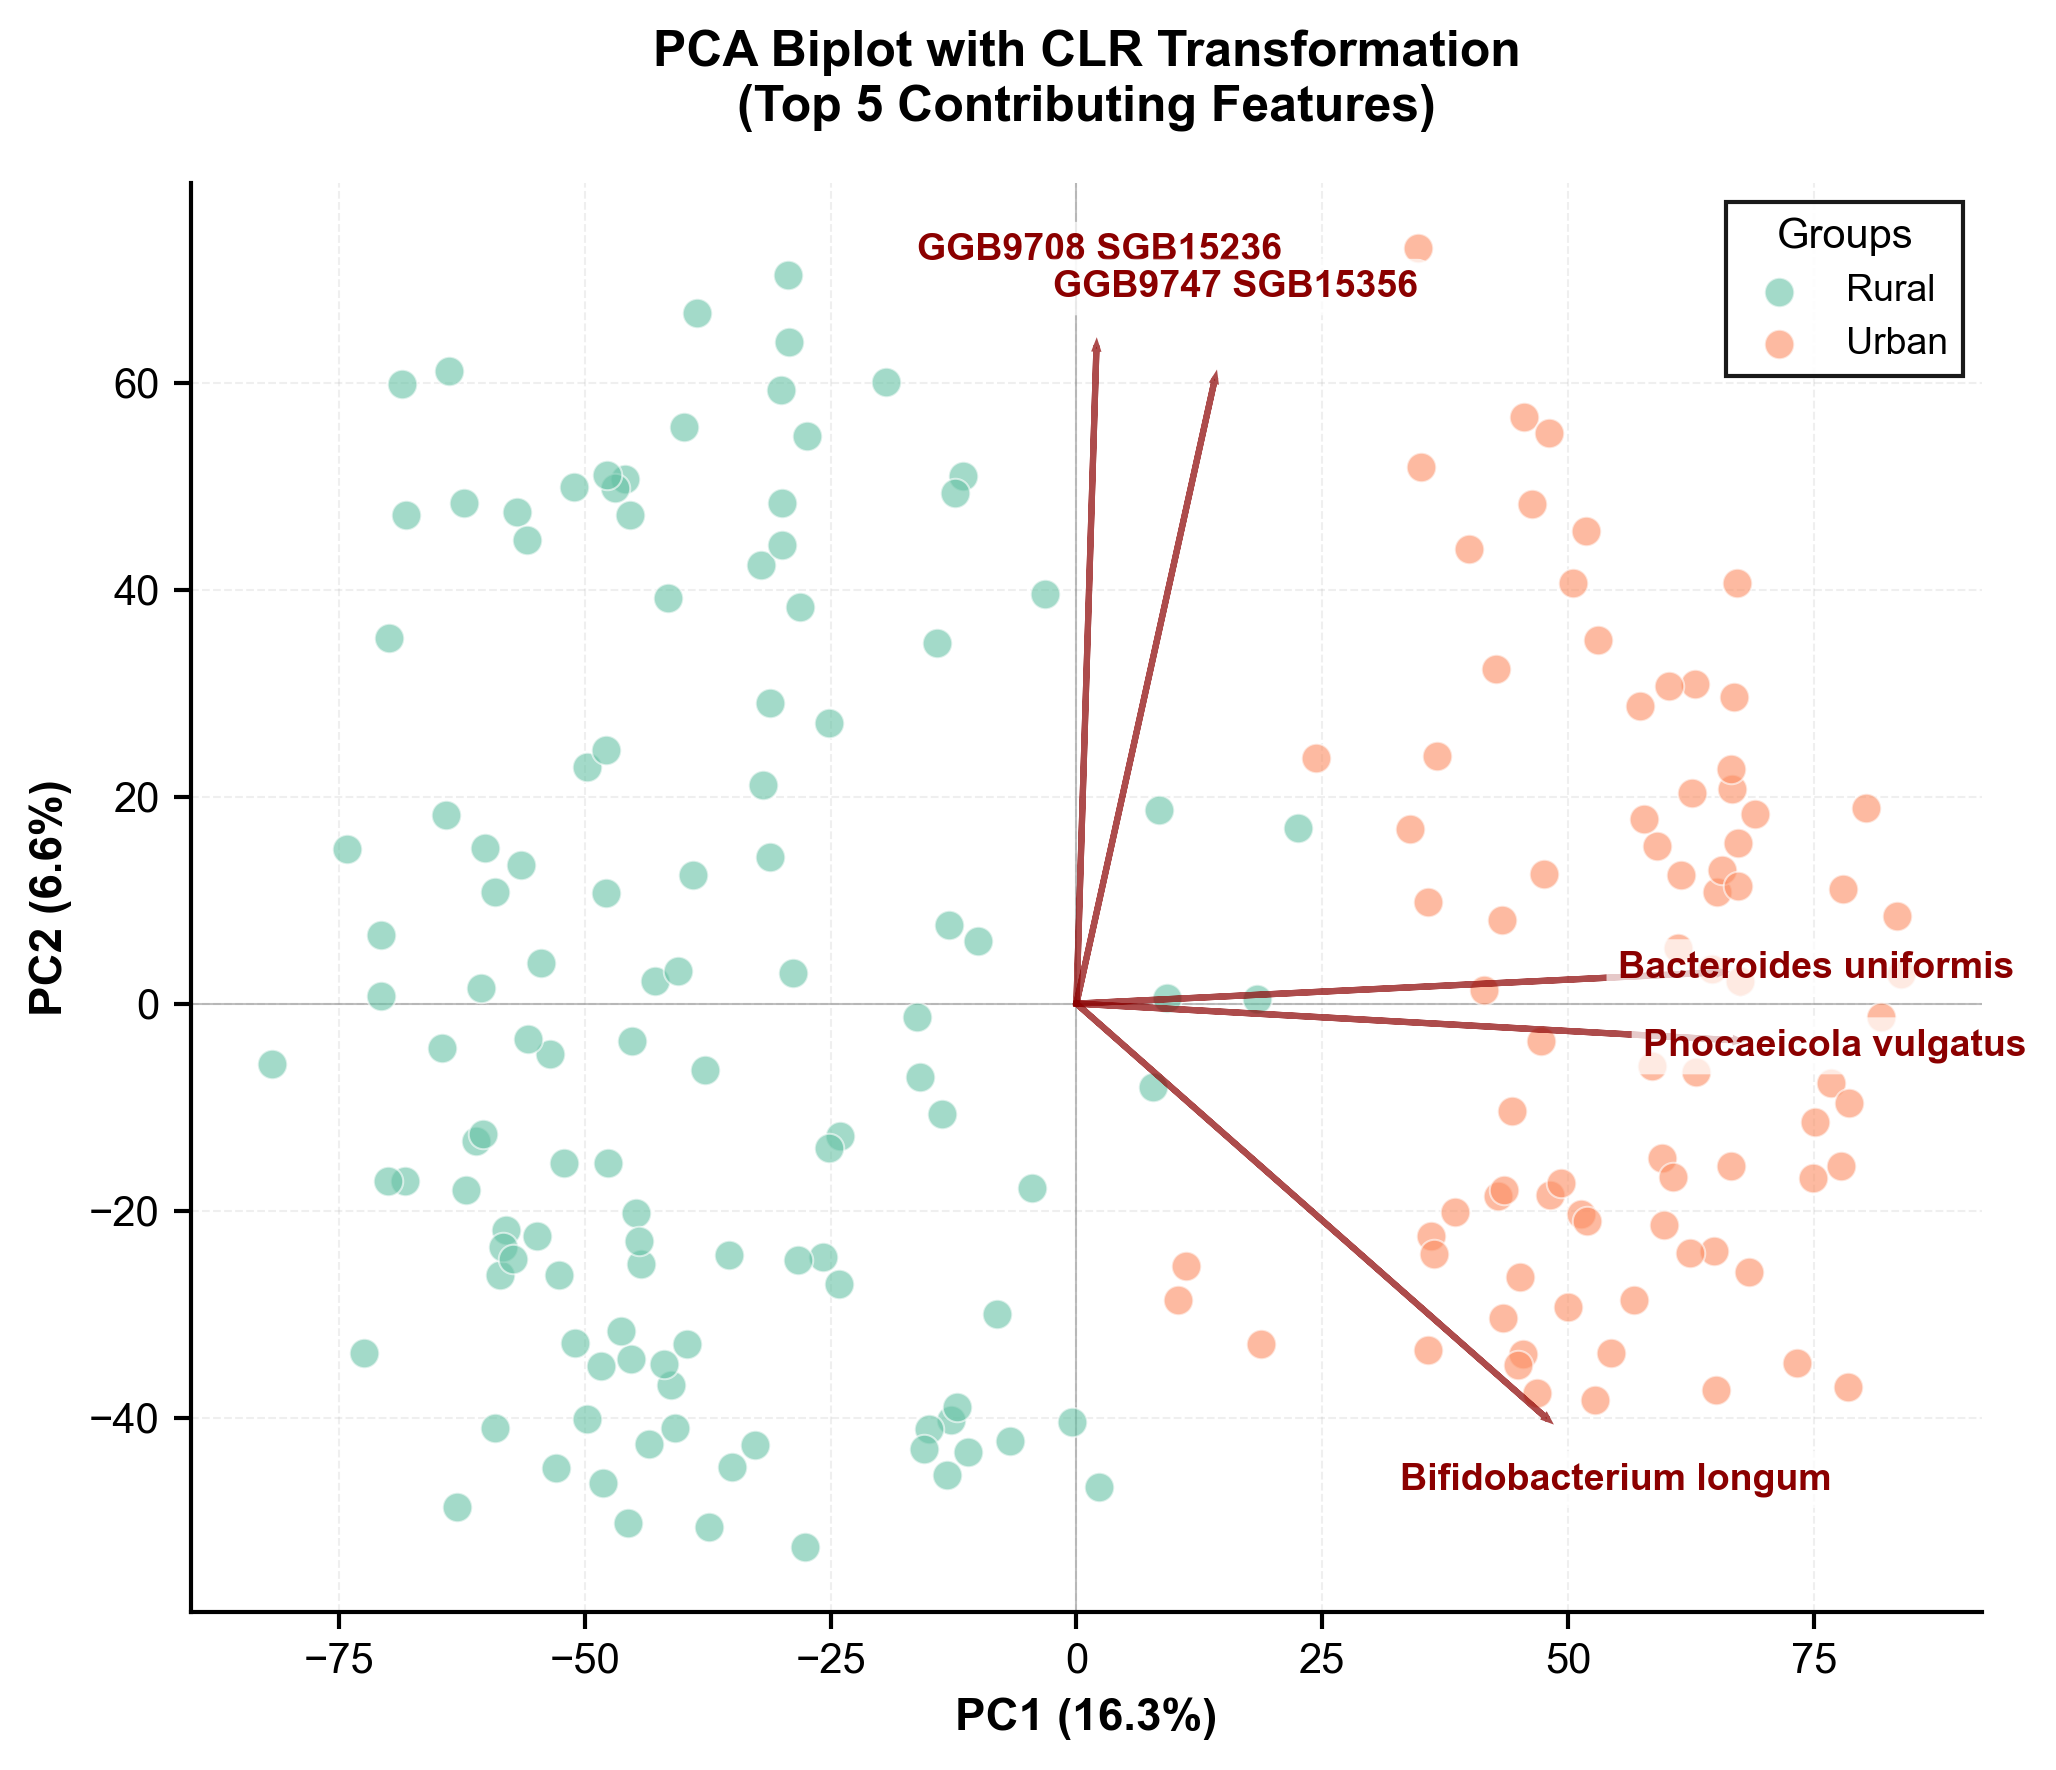

In [43]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.decomposition import PCA
#from adjustText import adjustText  # Optional: for better label positioning

# CLR transformation function
def clr_transform(X):
    """
    Apply Centered Log-Ratio (CLR) transformation to compositional data.
    
    Parameters:
    X : array-like, shape (n_samples, n_features)
        Compositional data (must be positive)
    
    Returns:
    X_clr : array, CLR-transformed data
    """
    # Add small constant to avoid log(0) if there are zeros
    X_safe = X + 1e-6
    
    # Compute geometric mean for each sample (row)
    geom_mean = np.exp(np.mean(np.log(X_safe), axis=1, keepdims=True))
    
    # CLR: log(x_i / geometric_mean)
    X_clr = np.log(X_safe / geom_mean)
    
    return X_clr

# Prepare data
X = data_sp_top.drop(columns=['label', 'age_group']).values
y = data_sp_top['label'].values
feature_names = data_sp_top.drop(columns=['label', 'age_group']).columns

# Apply CLR transformation
X_clr = clr_transform(X)

# Perform PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_clr)

# Loadings (contributions of original variables)
loadings = pca.components_.T  # shape: n_features x 2

# Compute contribution of each feature to PC1+PC2
contrib = np.linalg.norm(loadings, axis=1)  # Euclidean norm across PCs

# Select top 10 features by contribution
top_n = 5
top_idx = np.argsort(contrib)[-top_n:][::-1]  # indices of top features
top_features = feature_names[top_idx]

# Set journal-style parameters
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans']
plt.rcParams['font.size'] = 10
plt.rcParams['axes.linewidth'] = 1.0
plt.rcParams['xtick.major.width'] = 1.0
plt.rcParams['ytick.major.width'] = 1.0
plt.rcParams['xtick.major.size'] = 4
plt.rcParams['ytick.major.size'] = 4

# Create figure
fig, ax = plt.subplots(figsize=(7, 6), dpi=300)

# Get unique labels and colors
labels_unique = sorted(set(y))
colors = plt.cm.Set2.colors if len(labels_unique) <= 8 else plt.cm.tab10.colors

# Scatter plot of samples
for i, group in enumerate(labels_unique):
    idx = y == group
    ax.scatter(X_pca[idx, 0], X_pca[idx, 1], 
              alpha=0.6, 
              s=50, 
              label=group,
              color=colors[i % len(colors)],
              edgecolors='white',
              linewidths=0.5,
              zorder=2)

# Draw arrows for top features
scaling = np.max(np.abs(X_pca)) / np.max(np.abs(loadings)) * 0.8  # Auto-scale arrows
texts = []

for i in top_idx:
    # Draw arrow
    ax.arrow(0, 0, 
            loadings[i, 0] * scaling, 
            loadings[i, 1] * scaling, 
            color='darkred', 
            alpha=0.7, 
            head_width=0.15,
            head_length=0.2,
            linewidth=1.5,
            zorder=3)
    
    # Add text label
    text = ax.text(loadings[i, 0] * scaling * 1.15, 
                   loadings[i, 1] * scaling * 1.15, 
                   feature_names[i],
                   fontsize=9, 
                   color='darkred',
                   ha='center',
                   va='center',
                   fontweight='bold',
                   bbox=dict(boxstyle='round,pad=0.3', 
                           facecolor='white', 
                           edgecolor='none',
                           alpha=0.7),
                   zorder=4)
    texts.append(text)

# Optional: Use adjustText to prevent label overlap
# Uncomment if you have adjustText installed: pip install adjustText
# adjustText(texts, arrowprops=dict(arrowstyle='->', color='gray', lw=0.5))

# Format axes
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)', 
              fontsize=11, fontweight='bold')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)', 
              fontsize=11, fontweight='bold')
ax.set_title('PCA Biplot with CLR Transformation\n(Top 5 Contributing Features)', 
             fontsize=12, fontweight='bold', pad=15)

# Legend
ax.legend(frameon=True, 
          loc='best',
          fontsize=9,
          edgecolor='black',
          fancybox=False,
          shadow=False,
          framealpha=0.9,
          title='Groups',
          title_fontsize=10)

# Remove top and right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Add subtle grid
ax.grid(True, alpha=0.2, linestyle='--', linewidth=0.5, zorder=1)
ax.set_axisbelow(True)

# Add reference lines at origin
ax.axhline(y=0, color='gray', linestyle='-', linewidth=0.5, alpha=0.5, zorder=1)
ax.axvline(x=0, color='gray', linestyle='-', linewidth=0.5, alpha=0.5, zorder=1)

plt.tight_layout()
plt.show()

# Optional: Save as high-resolution files for publication
# fig.savefig('pca_biplot_clr.pdf', dpi=300, bbox_inches='tight')
fig.savefig('pca_biplot_clr.png', dpi=400, bbox_inches='tight')
# fig.savefig('pca_biplot_clr.svg', bbox_inches='tight')

In [83]:
!pip install adjustText

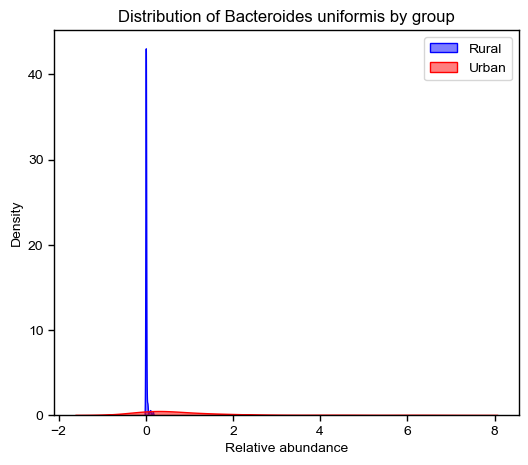

In [37]:
import seaborn as sns
import matplotlib.pyplot as plt

# Assume:
# data_sp_top = samples x features
# data_sp_top['label'] = 'Rural' / 'Urban'
# species_name = name of the species column you want to plot

species_name = 'Bacteroides uniformis'  # replace with your species

plt.figure(figsize=(6,5))
for group, color in zip(['Rural', 'Urban'], ['blue', 'red']):
    sns.kdeplot(data=data_sp_top[data_sp_top['label']==group][species_name],
                label=group, fill=True, alpha=0.5, color=color)
plt.title(f'Distribution of {species_name} by group')
plt.xlabel('Relative abundance')
plt.ylabel('Density')
plt.legend()
plt.show()

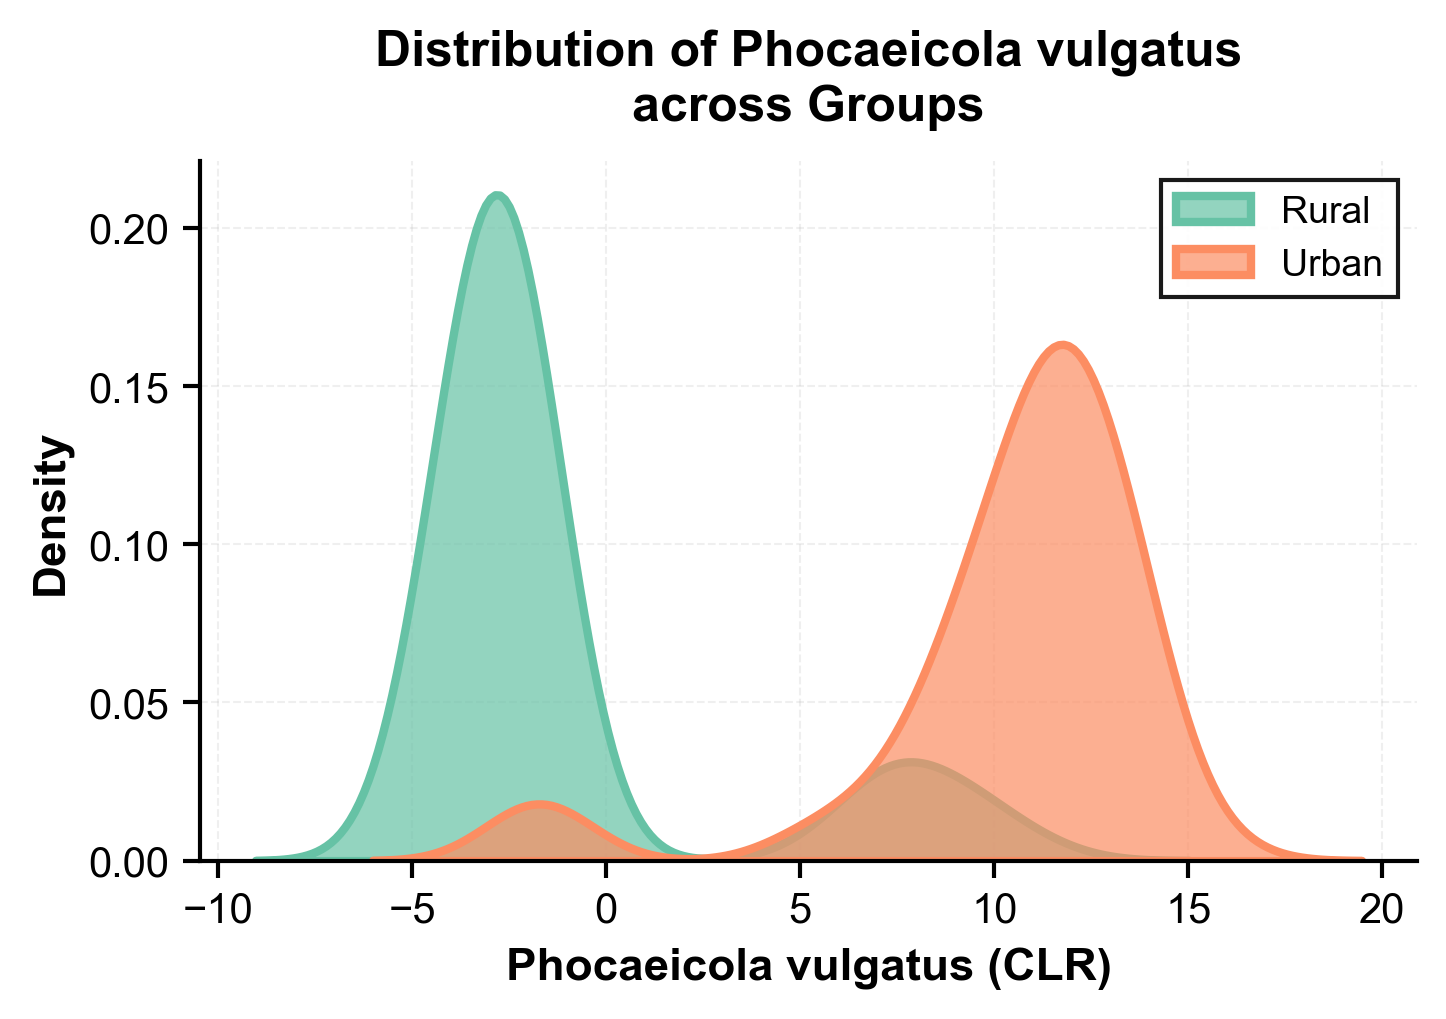

In [41]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from scipy import stats

def clr_transform(X):
    """Apply Centered Log-Ratio (CLR) transformation to compositional data."""
    X_safe = X + 1e-6
    geom_mean = np.exp(np.mean(np.log(X_safe), axis=1, keepdims=True))
    X_clr = np.log(X_safe / geom_mean)
    return X_clr

# Prepare data
X = data_sp_top.drop(columns=['label', 'age_group']).values
y = data_sp_top['label'].values
feature_names = data_sp_top.drop(columns=['label', 'age_group']).columns

# Apply CLR transformation
X_clr = clr_transform(X)

# Convert to DataFrame for easier handling
X_clr_df = pd.DataFrame(X_clr, columns=feature_names)
X_clr_df['label'] = y

# Choose your feature of interest
feature_of_interest = 'Phocaeicola vulgatus'  # Replace with actual feature name

# Set journal-style parameters
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans']
plt.rcParams['font.size'] = 10
plt.rcParams['axes.linewidth'] = 1.0

# Create figure
fig, ax = plt.subplots(figsize=(5, 3.5), dpi=300)

# Get unique labels and colors
labels_unique = sorted(set(y))
colors = plt.cm.Set2.colors if len(labels_unique) <= 8 else plt.cm.tab10.colors

# Plot KDE for each group
for i, group in enumerate(labels_unique):
    data_subset = X_clr_df[X_clr_df['label'] == group][feature_of_interest]
    
    # Plot KDE
    sns.kdeplot(data=data_subset, 
                ax=ax,
                label=group,
                color=colors[i % len(colors)],
                linewidth=2,
                alpha=0.7,
                fill=True,
                bw_adjust=0.8)  # Adjust bandwidth if needed

# Format axes
ax.set_xlabel(f'{feature_of_interest} (CLR)', fontsize=11, fontweight='bold')
ax.set_ylabel('Density', fontsize=11, fontweight='bold')
ax.set_title(f'Distribution of {feature_of_interest}\nacross Groups', 
             fontsize=12, fontweight='bold', pad=10)

# Legend
ax.legend(frameon=True,
          loc='best',
          fontsize=9,
          edgecolor='black',
          fancybox=False,
          framealpha=0.9)

# Remove top and right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Add grid
ax.grid(True, alpha=0.2, linestyle='--', linewidth=0.5)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

# Optional: Save figure
fig.savefig(f'kde_{feature_of_interest}_clr.pdf', dpi=300, bbox_inches='tight')

C:\Users\rafap\AppData\Local\Temp\ipykernel_9768\3344767278.py:18: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  plt.hexbin(x[idx], y[idx], C=None, gridsize=gridsize, cmap=plt.cm.get_cmap(cmap_name),


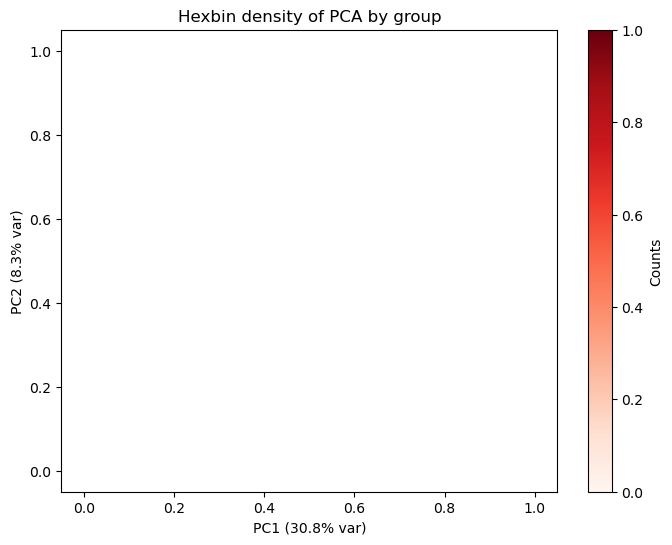

In [37]:
import matplotlib.pyplot as plt
import numpy as np

x = X_pca[:,0]
y = X_pca[:,1]
labels = label  # 'Rural' / 'Urban'

plt.figure(figsize=(8,6))

groups_unique = np.unique(labels)
colors = ['Blues', 'Reds']  # colormaps
alpha = 1
gridsize = 30

for group, cmap_name in zip(groups_unique, colors):
    idx = labels == group
    # hexbin needs a 'C' argument or it will default to counts
    plt.hexbin(x[idx], y[idx], C=None, gridsize=gridsize, cmap=plt.cm.get_cmap(cmap_name),
               alpha=alpha, mincnt=1)

plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)')
plt.title('Hexbin density of PCA by group')
plt.colorbar(label='Counts')
plt.show()



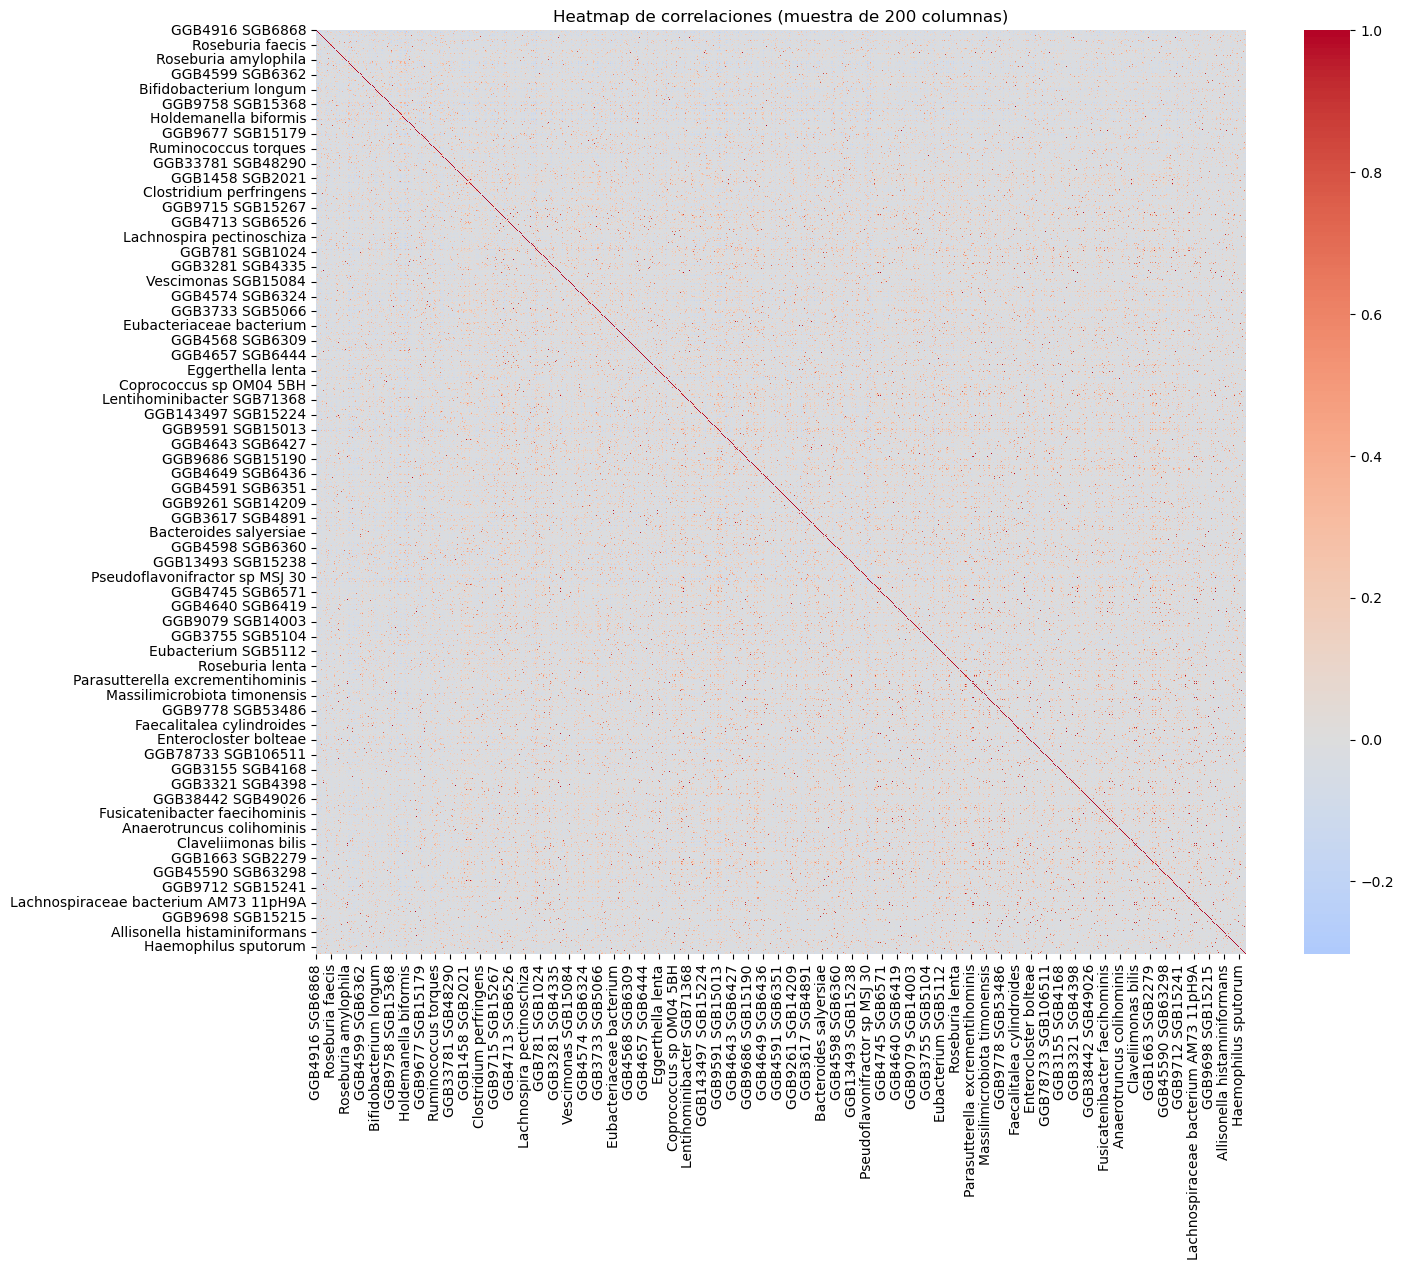

In [73]:
import seaborn as sns
# Calcular matriz de correlación
corr_matrix = data_sp_top.corr()

# Plot heatmap
plt.figure(figsize=(15,12))
sns.heatmap(corr_matrix, cmap='coolwarm', center=0)
plt.title('Heatmap de correlaciones (muestra de 200 columnas)')
plt.show()

In [74]:
rural = list(metadata[metadata['Lifestyle'] == 'Rural']['Lane'])
urban = list(metadata[metadata['Lifestyle'] == 'Urban']['Lane'])

In [75]:
rural_data = data_sp_top.loc[[x for x in rural if x in data_sp.index]]
urban_data = data_sp_top.loc[[x for x in urban if x in data_sp.index]]

In [62]:
rural_data

,GGB4916 SGB6868,Segatella copri,Agathobacter rectalis,Streptococcus gallolyticus,Ruminococcus bromii,Streptococcus salivarius,Faecalibacterium prausnitzii,Streptococcus lutetiensis,GGB4567 SGB6308,Escherichia coli,Ruminococcus bicirculans ex Wegman et al 2014,Methanobrevibacter smithii,Segatella sinensis,Catenibacterium mitsuokai,Segatella brunsvicensis,GGB3256 SGB4303,Roseburia faecis,Ligilactobacillus ruminis,Enterococcus hirae,GGB4611 SGB6385
37082_3#9,0.0000,0.08053,0.14987,0.0,3.07620,10.38913,0.11081,0.01526,0.0,3.69194,0.01868,0.00000,1.39044,0.74229,0.09810,0.01945,0.03991,0.00000,0.00951,0.00000
37082_3#8,0.0000,1.02161,0.23828,0.0,0.47133,0.05495,1.62658,0.00000,0.0,0.00000,0.17919,1.62892,0.56059,0.99527,0.22720,0.29593,0.00000,0.00000,0.00000,0.27553
37082_3#7,0.0926,0.09637,0.50272,0.0,0.31140,0.00000,0.16513,0.00000,0.0,0.00000,0.00000,5.57606,0.36469,0.19279,0.00000,0.03040,0.00000,0.00000,0.00000,0.25902
37082_3#6,0.0000,0.38928,1.41084,0.0,4.07755,0.05490,20.59416,0.10192,0.0,0.05219,0.00000,0.00971,0.74822,0.41872,0.00000,0.00000,0.47935,0.60072,0.00000,0.00000
37082_3#5,0.0000,2.08956,6.26731,0.0,5.17575,0.00000,3.13823,0.00000,0.0,0.00250,0.08318,2.89779,0.22416,4.24049,0.03797,0.43330,0.71920,0.52565,0.00000,0.00000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
36703_3#16,0.0000,2.26639,3.35523,0.0,0.29138,0.07955,1.50888,0.00000,0.0,0.00465,1.15367,2.33541,0.63973,0.82153,1.20984,0.00000,0.13855,0.00000,0.00000,0.00000
36703_3#15,0.0000,0.33110,44.21785,0.0,4.40569,1.10598,0.31872,0.00000,0.0,0.00000,0.00000,0.00000,0.06952,0.00000,0.00000,2.49404,0.01951,0.00000,0.00000,0.00000
36703_3#14,0.0000,15.70534,0.50370,0.0,2.33614,4.06460,0.48308,0.02112,0.0,0.03938,0.06138,0.00000,11.84416,1.78752,0.19317,0.00000,0.09756,0.81301,0.00000,0.04348
36703_3#13,0.0000,17.84466,7.22302,0.0,1.80281,0.29253,18.08928,0.00000,0.0,0.00720,0.02765,0.00000,1.02411,0.00000,1.22966,0.00000,2.00568,0.00000,0.00000,0.00000


In [76]:
urban_data

,GGB4916 SGB6868,Segatella copri,Agathobacter rectalis,Streptococcus gallolyticus,Ruminococcus bromii,Streptococcus salivarius,Faecalibacterium prausnitzii,Streptococcus lutetiensis,GGB4567 SGB6308,Escherichia coli,...,GGB51512 SGB71885,Enterococcus durans,Haemophilus sputorum,GGB9122 SGB14055,GGB100899 SGB146315,GGB6006 SGB8630,GGB6014 SGB8646,Alistipes dispar,GGB36267 SGB14177,Mediterraneibacter glycyrrhizinilyticus
37082_2#9,0.00000,1.38002,0.00000,0.00000,3.05001,0.00000,1.15341,0.00000,0.00050,0.05975,...,0.00000,0.0,0.0,0.0,0.0,0.0,0.0,0.00000,0.03649,0.00000
37082_2#8,0.00000,1.40202,0.01566,0.00000,0.00000,0.00000,1.14362,0.00000,0.00000,0.05983,...,0.00000,0.0,0.0,0.0,0.0,0.0,0.0,0.00000,0.00000,0.00000
37082_2#7,0.00000,0.00000,27.83627,0.00000,4.61010,0.00000,0.00000,0.00000,0.00000,0.00000,...,0.00000,0.0,0.0,0.0,0.0,0.0,0.0,0.00000,0.00000,0.00000
37082_2#6,0.00000,0.00000,30.82579,0.00000,0.32973,0.00491,2.63271,0.00000,0.00000,0.66333,...,0.00000,0.0,0.0,0.0,0.0,0.0,0.0,0.00000,0.00000,0.00000
37082_2#5,0.00000,0.34445,17.77671,0.00000,7.55254,0.33193,1.98643,0.13375,0.00000,0.78744,...,0.00000,0.0,0.0,0.0,0.0,0.0,0.0,0.00000,0.00000,0.12039
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
36703_3#5,0.32789,0.13356,0.09800,0.64017,2.76765,0.00352,0.13396,0.00000,47.93797,0.69181,...,0.00000,0.0,0.0,0.0,0.0,0.0,0.0,0.00000,0.01706,0.00000
36703_3#3,0.00000,38.61635,2.22241,0.00000,0.00000,0.08143,4.78679,0.00000,0.00000,0.00000,...,0.00000,0.0,0.0,0.0,0.0,0.0,0.0,0.00000,0.00000,0.00000
36703_3#2,0.00000,0.00594,2.24924,0.00000,0.00000,0.02976,19.26824,0.00000,0.00000,1.05870,...,0.00000,0.0,0.0,0.0,0.0,0.0,0.0,0.00000,0.00000,0.00000
36703_3#10,0.00000,0.00000,1.52041,0.00000,2.86484,0.19221,3.31411,0.00000,0.00000,0.26189,...,0.00000,0.0,0.0,0.0,0.0,0.0,0.0,0.00000,0.00000,0.00000


In [ ]:
from statsmodels.multivariate.manova import MANOVA
import pingouin as pg
import numpy as np

data = pd.concat([rural_data, urban_data])
data['group'] = ['Rural']*len(rural_data) + ['Urban']*len(urban_data)




# data: filas = muestras, columnas = features
# group: serie con la etiqueta del grupo
y = data.drop(columns='group').values  # variables dependientes
X = [0 if x == 'Rural' else 1 for x in data['group'].values]  # variable independiente codificada
print(y)
# print(X)

maov = MANOVA(endog=y, exog=X)
print(maov.mv_test())



# res = pg.manova(dv=data.drop(columns='group'), between=data_numeric['group'])
# print(res)

[[0.000000e+00 8.053000e-02 1.498700e-01 ... 0.000000e+00 0.000000e+00
  0.000000e+00]
 [0.000000e+00 1.021610e+00 2.382800e-01 ... 0.000000e+00 0.000000e+00
  0.000000e+00]
 [9.260000e-02 9.637000e-02 5.027200e-01 ... 0.000000e+00 0.000000e+00
  0.000000e+00]
 ...
 [0.000000e+00 5.940000e-03 2.249240e+00 ... 0.000000e+00 0.000000e+00
  0.000000e+00]
 [0.000000e+00 0.000000e+00 1.520410e+00 ... 0.000000e+00 0.000000e+00
  0.000000e+00]
 [0.000000e+00 0.000000e+00 1.222228e+01 ... 5.430000e-03 0.000000e+00
  2.908000e-02]]


Exception ignored in: <bound method IPythonKernel._clean_thread_parent_frames of <ipykernel.ipkernel.IPythonKernel object at 0x0000028006367110>>
Traceback (most recent call last):
  File "C:\Users\rafap\anaconda3\envs\clustering-env\Lib\site-packages\ipykernel\ipkernel.py", line 790, in _clean_thread_parent_frames
    active_threads = {thread.ident for thread in threading.enumerate()}
                                                 ^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\rafap\anaconda3\envs\clustering-env\Lib\threading.py", line 1501, in enumerate
    def enumerate():
    
KeyboardInterrupt: 
Exception ignored in: <bound method IPythonKernel._clean_thread_parent_frames of <ipykernel.ipkernel.IPythonKernel object at 0x0000028006367110>>
Traceback (most recent call last):
  File "C:\Users\rafap\anaconda3\envs\clustering-env\Lib\site-packages\ipykernel\ipkernel.py", line 775, in _clean_thread_parent_frames
    def _clean_thread_parent_frames(

KeyboardInterrupt: 


KeyboardInterrupt: 

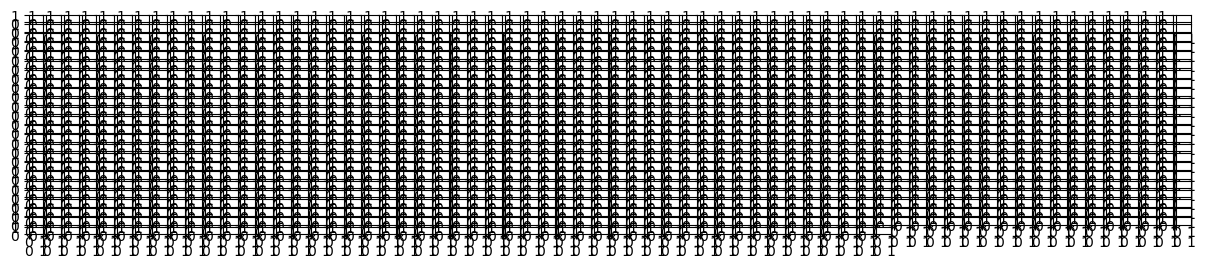

In [32]:
data_sp.hist(bins=50, figsize=(15,8))
plt.show()

In [3]:
import os

In [5]:
os.listdir('../datasets')

['2019_Aida_niños_ Microbioma Parasitos y Salud_ FINAL.xlsx',
 '41564_2018_337_MOESM4_ESM.xlsx',
 'Alimentos_Montaña-ciudad_2022.xlsx',
 'Alimentos_Montaña-Ciudad_Datos resumidos_2022.csv',
 'Base_MinEEG&Macronutrientes_7abril2020.xlsx',
 'BdD - AdultosMontañaAltadeGuerrero.xlsx',
 "BdD - HOMBRES ME'PHAA.xlsx",
 'BdD - Latinbiota.xlsx',
 'BdD - MICROBIOMA ADULTOS.xlsx',
 'BdD - Microbiota Niños ciudad vs Montaña.xlsx',
 'BdD - Proyecto Microbioma V.1.xlsx',
 'BdD - Proyectos Neuroecología.xlsx',
 'BdD-2024_Metadatos_Familias_Latinbiota.xlsx',
 'bracken_taxonomy.csv',
 'Datos encuestas Nutricionales_Ciudad .xlsx',
 'ec-predictions',
 'EEG_Nutrición_Niños_C y M_2022_RevCristian.xlsx',
 'Jesus Monteros_EEG_Nutricion Niños_Ciudad_y_Montaña.csv',
 'latinbiota_merge_metaphlan_data.tsv.csv',
 'latinbiota_pathabundance_stratified.tsv',
 'latinbiota_pathabundance_unstratified.tsv',
 'metadata_LATINBIOTA_MEXICO.xlsx',
 'module-prediction-human-01',
 'module-prediction-humann',
 'modul